# 🤖 Giai đoạn 3: Huấn luyện & So sánh các mô hình Machine Learning
Thử nghiệm Naive Bayes, Logistic Regression, SVM, Random Forest & Stacking Classifier.

**Nguyên tắc bắt buộc (theo kế hoạch nhóm):** `X_test` trong artifact của TV2 là **Final Test bị khóa**
(`final_test_policy: locked_not_evaluated_by_tv2`). TV3 **không được đánh giá trên X_test** — chỉ được dùng
Stratified 5-Fold Cross Validation trên `X_train` (Development set) để chọn và tune model. Model tốt nhất
sẽ được khóa và bàn giao cho **TV4**, người duy nhất được đánh giá trên Final Test (đúng 1 lần, ở notebook 05).

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import load_feature_split

artifact = load_feature_split(PROJECT_ROOT / 'models' / 'train_test_features.joblib')
if artifact['metadata'].get('feature_mode') != 'text_only':
    raise ValueError('Notebook TV3 yêu cầu artifact text-only.')

X_train, y_train = artifact['X_train'], artifact['y_train']
LABELS = ['Negative', 'Neutral', 'Positive']
print(f'Development set (X_train): {X_train.shape}')
print(f'Final Test bị khóa (không dùng ở notebook này): {artifact["X_test"].shape}')

# Chủ định: từ đây về sau, notebook này không bao giờ đụng lại đến artifact['X_test'] / artifact['y_test'].
del artifact

Development set (X_train): (6731, 5000)
Final Test bị khóa (không dùng ở notebook này): (1683, 5000)


## 3.1 So sánh chiến lược xử lý mất cân bằng: `class_weight='balanced'` vs SMOTE
SMOTE được bọc trong `imblearn.pipeline.Pipeline` để chỉ resample bên trong từng fold train của CV,
tránh rò rỉ dữ liệu (data leakage) từ fold validation.

In [2]:
from sklearn.model_selection import StratifiedKFold

from src.models import compare_imbalance_strategies, select_strategy_per_model

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026)

imbalance_comparison = compare_imbalance_strategies(X_train, y_train, cv=cv)
chosen_strategies = select_strategy_per_model(imbalance_comparison)

display(imbalance_comparison.sort_values(['Model', 'Strategy']).round(4))
print('Chiến lược được chọn cho mỗi model:', chosen_strategies)

,Model,Strategy,CV Macro F1 Mean,CV Macro F1 Std
4,Linear SVM,balanced,0.5531,0.0162
5,Linear SVM,smote,0.5431,0.0194
2,Logistic Regression,balanced,0.5719,0.0130
3,Logistic Regression,smote,0.5727,0.0108
0,Multinomial Naive Bayes,balanced,0.3581,0.0035
1,Multinomial Naive Bayes,smote,0.5493,0.0197
6,Random Forest,balanced,0.5224,0.0207
7,Random Forest,smote,0.4779,0.0129


Chiến lược được chọn cho mỗi model: {'Linear SVM': 'balanced', 'Logistic Regression': 'smote', 'Multinomial Naive Bayes': 'smote', 'Random Forest': 'balanced'}


## 3.2 Tinh chỉnh siêu tham số (Hyperparameter Tuning)
`GridSearchCV` với `scoring='f1_macro'` trên `StratifiedKFold(5)`, chỉ trên `X_train`.
Tinh chỉnh: `alpha` (Naive Bayes), `C` (Logistic Regression, Linear SVM), `n_estimators`/`max_depth` (Random Forest).

In [3]:
from src.models import tune_models

tuned_models = tune_models(X_train, y_train, strategies=chosen_strategies, cv=cv)

for name, search in tuned_models.items():
    print(f'{name}: CV Macro F1 = {search.best_score_:.4f} | best params = {search.best_params_}')

Multinomial Naive Bayes: CV Macro F1 = 0.5534 | best params = {'clf__alpha': 0.5}
Logistic Regression: CV Macro F1 = 0.5727 | best params = {'clf__C': 1.0}
Linear SVM: CV Macro F1 = 0.5724 | best params = {'clf__C': 0.1}
Random Forest: CV Macro F1 = 0.5664 | best params = {'clf__max_depth': 30, 'clf__n_estimators': 400}


## 3.3 Stacking Ensemble Classifier
Base learners = `[MNB, LR, LinearSVC, RF]` (đã tune ở trên) → Meta-learner = `LogisticRegression`, `cv=5`.

In [4]:
from sklearn.model_selection import cross_val_score

from src.models import build_stacking

stacking_model = build_stacking(tuned_models, cv=5)
stacking_scores = cross_val_score(stacking_model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print(f'Stacking Ensemble: CV Macro F1 = {stacking_scores.mean():.4f} (+/- {stacking_scores.std():.4f})')

Stacking Ensemble: CV Macro F1 = 0.5560 (+/- 0.0237)


## 3.4 Bảng tổng hợp & chọn mô hình tốt nhất (theo CV trên Development set)
Bảng này dùng để viết Mục 3.4 & 5.1 của báo cáo. Đây **không phải** kết quả Final Test.

In [5]:
from src.models import STACKING_BASE_ORDER, summarize_results

results_summary = summarize_results(tuned_models, stacking_scores)
display(results_summary)

best_row = results_summary.iloc[0]
best_model_name = best_row['Model']
print(f'Mô hình được chọn (CV Macro F1 cao nhất trên Development set): {best_model_name}')

if best_model_name == 'Stacking Ensemble':
    selected_estimator = build_stacking(tuned_models, cv=5)
else:
    selected_estimator = tuned_models[best_model_name].best_estimator_

,Model,CV Macro F1 Mean,CV Macro F1 Std,Best Params
0,Logistic Regression,0.572705,0.010803,{'clf__C': 1.0}
1,Linear SVM,0.572392,0.025989,{'clf__C': 0.1}
2,Random Forest,0.566381,0.013763,"{'clf__max_depth': 30, 'clf__n_estimators': 400}"
3,Stacking Ensemble,0.556037,0.023712,{'cv': 5}
4,Multinomial Naive Bayes,0.553418,0.018340,{'clf__alpha': 0.5}


Mô hình được chọn (CV Macro F1 cao nhất trên Development set): Logistic Regression


## 3.5 Chẩn đoán lỗi trên Development set (CV out-of-fold, không dùng Final Test)
Confusion matrix này phục vụ phân tích Overfitting/Underfitting và nguyên nhân nhầm lẫn (Mục 3.4/5.1),
dựa trên dự đoán out-of-fold của CV — không phải kết quả Final Test chính thức.

Đã lưu biểu đồ tại: E:\projects\ML-Sentiment-Analysis-ITviec\reports\figures\tv3_cv_confusion_matrix.png


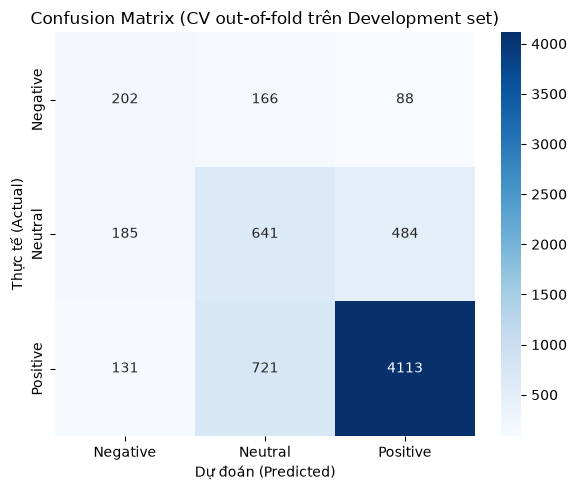

In [6]:
from src.models import plot_cv_confusion_matrix

plot_cv_confusion_matrix(
    selected_estimator,
    X_train,
    y_train,
    cv=cv,
    labels=LABELS,
    save_path=PROJECT_ROOT / 'reports' / 'figures' / 'tv3_cv_confusion_matrix.png',
)

## 3.6 Khóa mô hình tốt nhất và bàn giao cho TV4
Refit mô hình được chọn trên toàn bộ `X_train` (Development, 80%) rồi lưu lại.
TV4 sẽ tự nạp lại `X_test` ở notebook 05 để đánh giá Final Test **đúng 1 lần**.

In [7]:
from src.models import lock_best_model, save_model

locked_model = lock_best_model(selected_estimator, X_train, y_train)
model_path = PROJECT_ROOT / 'models' / 'best_sentiment_model.joblib'
save_model(locked_model, model_path)
print(f"Đã khóa và lưu mô hình '{best_model_name}' tại {model_path}")
print('Lưu ý bàn giao: model này chưa từng được đánh giá trên Final Test (X_test).')

Đã khóa và lưu mô hình 'Logistic Regression' tại E:\projects\ML-Sentiment-Analysis-ITviec\models\best_sentiment_model.joblib
Lưu ý bàn giao: model này chưa từng được đánh giá trên Final Test (X_test).
